<h1>
  <span class="prefix"></span>
  <span class="headline">Data Science Fundamentals - Lab - Titanic EDA</span>
</h1>

## About
For this lab, we're going to take a look at the Titanic manifest. We'll be exploring this data to see what we can learn regarding the survival rates of different groups of people.

## Submission
Lab submissions should be made as per guidance from your instructor. Your submission will be in the form of a link to your Github fork of this repository.

## Prework
Sync your fork to the repo.

## Step 1: Reading the data

In the [notebook](./lab-eda-titanic-student-submission.ipynb) provided, do the following:

1. Import `pandas` and `matplotlib.pyplot`
1. Load [train.csv](./train.csv) as a `pandas` DataFrame.
1. In each of the following sections, copy the question as a python comment, then answer the question with your own code.
1. Refer to the [Titanic Kaggle competition](https://www.kaggle.com/c/titanic/data) if you need an explanation for any of the columns.


In [63]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb
import re

In [64]:
titanic = pd.read_csv("https://raw.githubusercontent.com/Ch3ddarr/DSB-Unit-02/refs/heads/main/Labs/lab-eda-titanic/titanic-train.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Step 2: Cleaning the data

1. Create a bar chart showing how many missing values are in each column
  - *Bonus* : Theres a good library for visualizing missing values called Missingno.
      - [Install Instructions](https://pypi.org/project/missingno/)
      - [Usage Documentation](https://github.com/ResidentMario/missingno)


In [4]:
import missingno as ms

<Axes: >

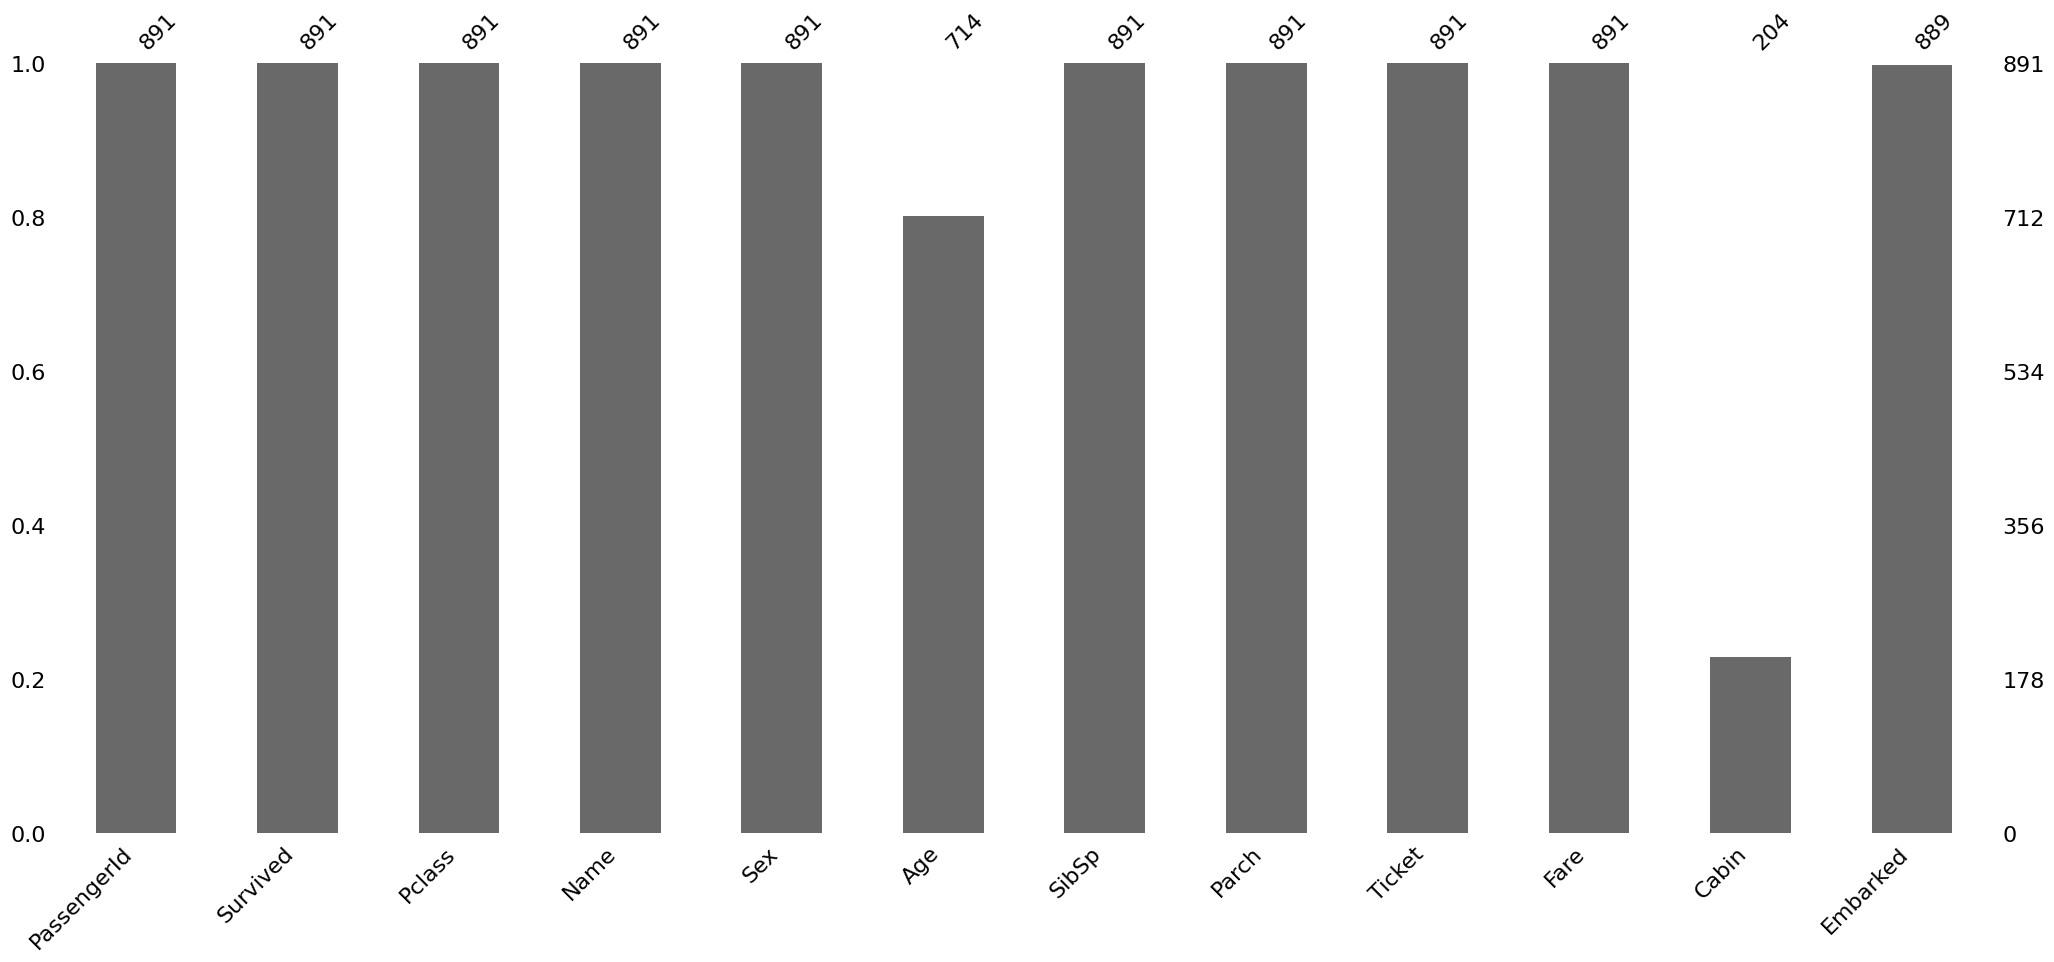

In [5]:
ms.bar(titanic)

2. Which column has the most `NaN` values? How many cells in that column are empty?


In [6]:
# int(titanic[titanic['Cabin'].isnull()].count()['PassengerId'])
num = 0
nam = ''
for x in titanic.columns:
  if int(titanic[titanic[x].isnull()].count()['PassengerId']) > num:
    num = int(titanic[titanic[x].isnull()].count()['PassengerId'])
    nam = x
  else:
    pass

print(f'Column "{nam}" has the most ({num}) NaN values!')

# STUDENT NOTE:There definetely was an easier way to do this but I decided to do
# it my way just for the love of the game



Column "Cabin" has the most (687) NaN values!



3. Delete all rows where `Embarked` is empty


In [7]:
titanic_without_embarked_empty_cells = titanic.dropna(subset=['Embarked'])
titanic_without_embarked_empty_cells.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB



4. Fill all empty cabins with **¯\\_(ツ)_/¯**

Note: `NaN`, empty, and missing are synonymous.



In [8]:
titanic_with_silly_face = titanic.copy()
titanic_with_silly_face['Cabin'] = titanic_with_silly_face['Cabin'].fillna(r"¯\(ツ)/¯")
titanic_with_silly_face.T

# STUDENT NOTE: I used Transversal view in order to show that I managed to do
# it.
# When I did normal show like we do in the class I don't see it the way it's
# supposed to look. I spent 15 minutes trying to figure out why is this not
# working when I did everything right.

,0,1,2,3,4,5,6,7,8,9,...,881,882,883,884,885,886,887,888,889,890
PassengerId,1,2,3,4,5,6,7,8,9,10,...,882,883,884,885,886,887,888,889,890,891
Survived,0,1,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,1,0,1,0
Pclass,3,1,3,1,3,3,1,3,3,2,...,3,3,2,3,3,2,1,3,1,3
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th...","Heikkinen, Miss. Laina","Futrelle, Mrs. Jacques Heath (Lily May Peel)","Allen, Mr. William Henry","Moran, Mr. James","McCarthy, Mr. Timothy J","Palsson, Master. Gosta Leonard","Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)","Nasser, Mrs. Nicholas (Adele Achem)",...,"Markun, Mr. Johann","Dahlberg, Miss. Gerda Ulrika","Banfield, Mr. Frederick James","Sutehall, Mr. Henry Jr","Rice, Mrs. William (Margaret Norton)","Montvila, Rev. Juozas","Graham, Miss. Margaret Edith","Johnston, Miss. Catherine Helen ""Carrie""","Behr, Mr. Karl Howell","Dooley, Mr. Patrick"
Sex,male,female,female,female,male,male,male,male,female,female,...,male,female,male,male,female,male,female,female,male,male
Age,22.0,38.0,26.0,35.0,35.0,NaN,54.0,2.0,27.0,14.0,...,33.0,22.0,28.0,25.0,39.0,27.0,19.0,NaN,26.0,32.0
SibSp,1,1,0,1,0,0,0,3,0,1,...,0,0,0,0,0,0,0,1,0,0
Parch,0,0,0,0,0,0,0,1,2,0,...,0,0,0,0,5,0,0,2,0,0
Ticket,A/5 21171,PC 17599,STON/O2. 3101282,113803,373450,330877,17463,349909,347742,237736,...,349257,7552,C.A./SOTON 34068,SOTON/OQ 392076,382652,211536,112053,W./C. 6607,111369,370376
Fare,7.25,71.2833,7.925,53.1,8.05,8.4583,51.8625,21.075,11.1333,30.0708,...,7.8958,10.5167,10.5,7.05,29.125,13.0,30.0,23.45,30.0,7.75


## Step 3: Feature extraction
1.  There are two columns that pertain to how many family members are on the boat for a given person. Create a new column called `FamilyCount` which will be the sum of those two columns.

In [9]:
famtitanic = titanic.copy()
famtitanic['FamilyCount'] = famtitanic['SibSp'] + famtitanic['Parch']
famtitanic[famtitanic['FamilyCount'] > 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,4
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,2
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,2
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S,6
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S,10
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S,2
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,2
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,5



2. Reverends have a special title in their name. Create a column called `IsReverend`: 1 if they're a preacher, 0 if they're not.


In [10]:
# titanic[titanic['Name'].str.contains('reverend', case=False)]
# I checked with this for loop if the column 'Name' has any reverends.
# I found this definition: “Reverend” is an honorific style used before the name
# of ordained Christian clergy, derived from the Latin reverendus meaning
# “worthy of reverence,” and commonly abbreviated as Rev., Revd, or Rev’d.
# However I haven't found any matchings for Revd or Rev'd so I conclude only
# Rev. exists

titanicrev = titanic.copy()
titanicrev['IsReverend'] = 0

# Good logic bad syntax!!!!
# for x in titanic['Name']:
#   if "Rev" in x:
#     titanicrev[titanic['Name'] == x]['IsReverend'] = 1
#   else:
#     pass

for x in titanic['Name']:
  if "Rev." in x:
    titanicrev.loc[titanicrev['Name'] == x, 'IsReverend'] = 1

titanicrev[titanicrev['IsReverend'] == 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,IsReverend
149,150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.0,0,0,244310,13.000,NaN,S,1
150,151,0,2,"Bateman, Rev. Robert James",male,51.0,0,0,S.O.P. 1166,12.525,NaN,S,1
249,250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.000,NaN,S,1
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.350,NaN,Q,1
848,849,0,2,"Harper, Rev. John",male,28.0,0,1,248727,33.000,NaN,S,1
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.000,NaN,S,1


3. In order to feed our training data into a classification algorithm, we need to convert our categories into 1's and 0's using `pd.get_dummies`
  - Familiarize yourself with the [`pd.get_dummies` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)
  - Create 3 columns: `Embarked_C`, `Embarked_Q` and `Embarked_S`. These columns will have 1's and 0's that correspond to the `C`, `Q` and `S` values in the `Embarked` column
  - Do the same thing for `Sex`
  - BONUS: Extract the title from everyone's name and create dummy columns

In [11]:
dummyEMBtitanic = titanic.copy()

EmbarkedCol = pd.get_dummies(dummyEMBtitanic['Embarked'], prefix = 'Embarked', dtype=int)
SexCol = pd.get_dummies(dummyEMBtitanic['Sex'], prefix = 'Sex', dtype=int)

dummyEMBtitanic = pd.concat([dummyEMBtitanic, EmbarkedCol, SexCol], axis=1)
dummyEMBtitanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,0,1,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0,1,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,1


## Step 4: Exploratory analysis
_[`df.groupby()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html) may be very useful._

1. What was the survival rate overall?
2. Which gender fared the worst? What was their survival rate?
3. What was the survival rate for each `Pclass`?
4. Did any reverends survive? How many?
5. What is the survival rate for cabins marked **¯\\_(ツ)_/¯**
6. What is the survival rate for people whose `Age` is empty?
7. What is the survival rate for each port of embarkation?
8. What is the survival rate for children (under 12) in each `Pclass`?
9. Did the captain of the ship survive? Is he on the list?
10. Of all the people that died, who had the most expensive ticket? How much did it cost?
11. Does having family on the boat help or hurt your chances of survival?

In [12]:
# 1. What was the survival rate overall?

num_of_pass = titanic.shape[0]
survival_rate = float(round((titanic.groupby('Survived')['PassengerId'].count()[1] / num_of_pass * 100), 2))
print(f"Overall survival rate is {survival_rate}%")

Overall survival rate is 38.38%


In [13]:
# 2. Which gender fared the worst? What was their survival rate?

num_of_fem = titanic.groupby('Sex')['PassengerId'].count().iloc[0]
num_of_mal = titanic.groupby('Sex')['PassengerId'].count().iloc[1]

if num_of_fem > num_of_mal:
  print('Males fared the worst!')
else:
  print('Females fared the worst!')

# print(num_of_fem) #314
# print(num_of_mal) #577

df_sex_survived_count = titanic.groupby('Sex')['Survived'].value_counts()

perc_fem_surv = round((df_sex_survived_count.iloc[0] / num_of_fem * 100), 2)
perc_mal_surv = round((df_sex_survived_count.iloc[2] / num_of_mal * 100), 2)

print(f"Percentage of males who survived is {perc_mal_surv}% while percentage of females who survived is {perc_fem_surv}%")


Females fared the worst!
Percentage of males who survived is 81.11% while percentage of females who survived is 74.2%


In [14]:
# 3. What was the survival rate for each Pclass?
values = titanic['Pclass'].unique()
titanic.groupby('Pclass')[['Survived']].value_counts()

# values for pclass 3 (values[0])
# surv_pclass3_num --> number of people who survived that are from pclass3
# totalpclass3 --> total number of people in pclass 3
# perc_pclass3 --> percentage of people who survived from pclass 3
surv_pclass3_num = titanic[titanic['Pclass']==values[0]].groupby('Pclass')[['Survived']].value_counts().iloc[1]
totalpclass3 = titanic[titanic['Pclass']==values[0]].describe()['Pclass'].iloc[0]
perc_pclass3 = round((surv_pclass3_num / totalpclass3 * 100), 2)
print(f"Percantage of people that survived in Pclass 3 is {perc_pclass3}%!!!")

# values for pclass 1 (values[1])
# surv_pclass1_num --> number of people who survived that are from pclass3
# totalpclass1 --> total number of people in pclass 3
# perc_pclass1 --> percentage of people who survived from pclass 3
surv_pclass1_num = titanic[titanic['Pclass']==values[1]].groupby('Pclass')[['Survived']].value_counts().iloc[1]
totalpclass1 = titanic[titanic['Pclass']==values[1]].describe()['Pclass'].iloc[0]
perc_pclass1 = round((surv_pclass1_num / totalpclass1 * 100), 2)
print(f"Percantage of people that survived in Pclass 1 is {perc_pclass1}%!!!")

# values for pclass 2 (values[2])
# surv_pclass2_num --> number of people who survived that are from pclass3
# totalpclass2 --> total number of people in pclass 3
# perc_pclass2 --> percentage of people who survived from pclass 3
surv_pclass2_num = titanic[titanic['Pclass']==values[2]].groupby('Pclass')[['Survived']].value_counts().iloc[1]
totalpclass2 = titanic[titanic['Pclass']==values[2]].describe()['Pclass'].iloc[0]
perc_pclass2 = round((surv_pclass2_num / totalpclass2 * 100), 2)
print(f"Percantage of people that survived in Pclass 2 is {perc_pclass2}%!!!")

Percantage of people that survived in Pclass 3 is 24.24%!!!
Percantage of people that survived in Pclass 1 is 37.04%!!!
Percantage of people that survived in Pclass 2 is 47.28%!!!


In [15]:
# 4. Did any reverends survive? How many?
num_of_surv_rev = titanicrev[titanicrev['IsReverend']==1][titanic['Survived']==1]['PassengerId'].count()
print(f"Looks like {num_of_surv_rev} reverends survived.")

Looks like 0 reverends survived.


/tmp/ipykernel_1017/1669289947.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_of_surv_rev = titanicrev[titanicrev['IsReverend']==1][titanic['Survived']==1]['PassengerId'].count()


In [16]:
# 5. What is the survival rate for cabins marked ¯\(ツ)/¯
perc = titanic_with_silly_face[titanic_with_silly_face['Cabin'] == r"¯\(ツ)/¯"].groupby('Survived')['PassengerId'].count().iloc[1] / (titanic_with_silly_face[titanic_with_silly_face['Cabin'] == r"¯\(ツ)/¯"].groupby('Survived')['PassengerId'].count().iloc[1] + titanic_with_silly_face[titanic_with_silly_face['Cabin'] == r"¯\(ツ)/¯"].groupby('Survived')['PassengerId'].count().iloc[0]) * 100
print(f"Percentage of survival for cabins marked with silly face is {perc:.2f}")

Percentage of survival for cabins marked with silly face is 29.99


In [17]:
# 6. What is the survival rate for people whose Age is empty?.
print(f"Survival rate for people whose Age is empty is {round(titanic[titanic['Age'].isnull()]['Survived'].mean()*100,2)}")

Survival rate for people whose Age is empty is 29.38


In [18]:
# 7. What is the survival rate for each port of embarkation?
survivaldf = titanic.groupby('Embarked')['Survived'].mean().round(4)*100
print(f"Survival rate for Embarked C port {survivaldf.iloc[0]}%")
print(f"Survival rate for Embarked Q port {survivaldf.iloc[1]}%")
print(f"Survival rate for Embarked S port {survivaldf.iloc[2]}%")


Survival rate for Embarked C port 55.36%
Survival rate for Embarked Q port 38.96%
Survival rate for Embarked S port 33.7%


In [19]:
# 8. What is the survival rate for children (under 12) in each Pclass?
kids = titanic[titanic['Age'] < 12].groupby('Pclass')['Survived'].mean().round(4)*100
print(f"Survival rate for kids in Pclass 1 {kids.iloc[0]}%")
print(f"Survival rate for kids in Pclass 2 {kids.iloc[1]}%")
print(f"Survival rate for kids in Pclass 3 {kids.iloc[2]}%")


Survival rate for kids in Pclass 1 75.0%
Survival rate for kids in Pclass 2 100.0%
Survival rate for kids in Pclass 3 40.43%


In [20]:
# 9. Did the captain of the ship survive? Is he on the list?
titanic[titanic['Name'].str.contains('Smith, Mr. Edward', case=False)]

# I searched online on what was the name of the captain and found that his name
# was Edward Smith. However, it looks like he is not on the list because
# which makes sense because he is not a passanger but a member of the staff
# and we know that index for this DataFrame is "PassengerId" which he cannot
# fall under so the answer is 0

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [21]:
# 10. Of all the people that died, who had the most expensive ticket? How much did it cost?
print(f"The most expensive ticket out of people that died cost {titanic[titanic['Survived']==0]['Fare'].max()}")

The most expensive ticket out of people that died cost 263.0


In [22]:
# 11. Does having family on the boat help or hurt your chances of survival?
titanic['Family'] = (titanic['Parch'] + titanic['SibSp']) > 0
survival_rate = titanic.groupby('Family')['Survived'].mean().round(3)*100
print(f"Survival rate for people without family is {survival_rate.iloc[0]}%")
print(f"Survival rate for people with family is {survival_rate.iloc[1]}%")

# The point is: Make a family!

Survival rate for people without family is 30.4%
Survival rate for people with family is 50.6%


## Step 5: Plotting
Using `matplotlib` and `seaborn`, create several charts showing the survival rates of different groups of people. It's fine if a handful of charts are basic (Gender, Age, etc), but what we're really looking for is something beneath the surface.

---

## Important note
Please ignore the `_layouts` folder and the `config.yml` file in the root of this repo.  They are needed to make sure the repo renders well; please don't change them or delete them and your repo will work fine :)

In [62]:
# I'm gonna explore survival late

titanic['Family'] = titanic['SibSp'] + titanic['Parch'] + 1 # I guess I should add the person whose data I'm taking

familysurvival = titanic.groupby('Family')['Survived'].agg(['mean', 'count']) # array([ 1,  8,  4,  2,  6,  5,  3,  7, 11])

<function matplotlib.pyplot.show(close=None, block=None)>

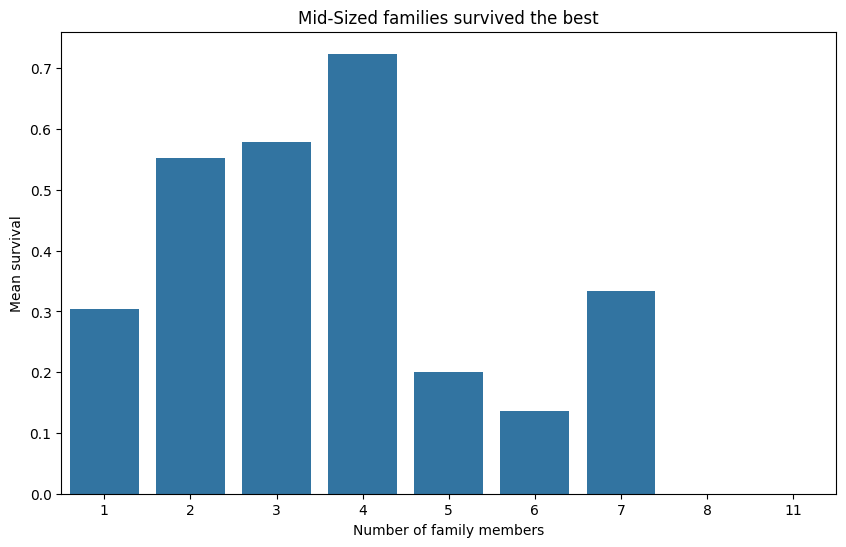

In [55]:
mp.figure(figsize=(10,6))

sb.barplot(
    data = familysurvival,
    x = 'Family',
    y = 'mean'
)

mp.title('Mid-Sized families survived the best')
mp.xlabel('Number of family members')
mp.ylabel('Mean survival')

mp.show


/tmp/ipykernel_1017/1870578749.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  faregroupsurvival = titanic.groupby('FareGroup').agg(AverageFare=('Fare', 'mean'), SurvivalRate=('Survived', 'mean'))


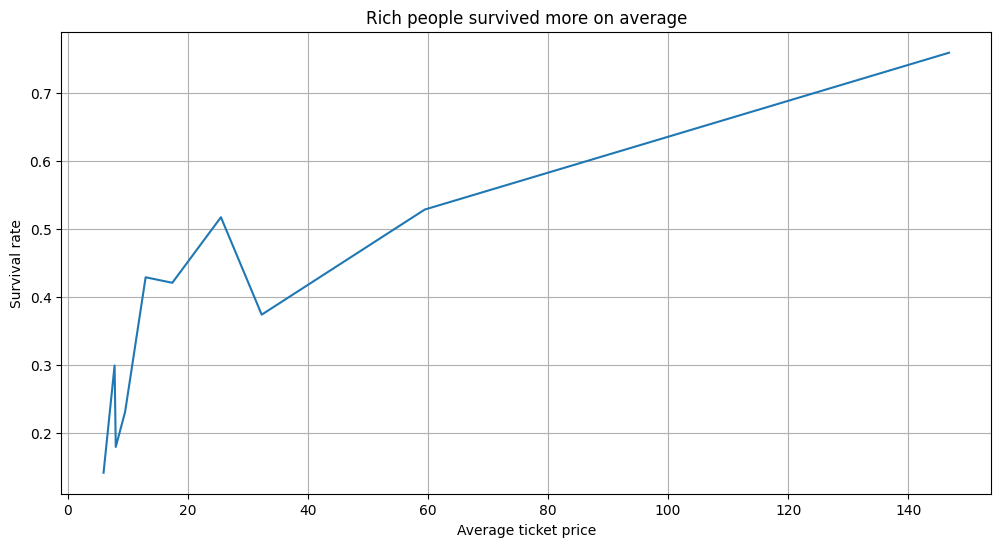

In [83]:
# I want to see if people who payed more for the tickets survived better

# Division of people into 10 groups per fare cost
titanic['FareGroup'] = pd.qcut(titanic['Fare'], q=10, duplicates='drop')

# Calculation of survival rate for each faregroup
faregroupsurvival = titanic.groupby('FareGroup').agg(AverageFare=('Fare', 'mean'), SurvivalRate=('Survived', 'mean'))
#faregroupsurvival


mp.figure(figsize=(12,6))

mp.plot(
    faregroupsurvival['AverageFare'],
    faregroupsurvival['SurvivalRate']
)

mp.title('Rich people survived more on average')
mp.xlabel('Average ticket price')
mp.ylabel('Survival rate')
mp.grid(True)


mp.show()